# Random Forest

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

X_train = pd.read_csv("../data/furtherprocessed/X_train.csv")
y_train = pd.read_csv("../data/furtherprocessed/y_train.csv")

X_test = pd.read_csv("../data/furtherprocessed/X_test.csv")
y_test = pd.read_csv("../data/furtherprocessed/y_test.csv")


## Baseline Model

In [2]:
# 1) build model
rf = RandomForestClassifier(
    n_estimators=200,
    # Uses all available CPU cores to speed up training.
    random_state=42,
    # Uses all available CPU cores to speed up training.
    n_jobs=-1,
    class_weight="balanced"   # crime data often imbalanced
)

# 2) train
y_train = y_train.values.ravel()

rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Hyperparameter tuning & Cross validation

In [3]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Stratified k-fold cross validation ,k=5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#coarse search
param_grid = {
    ## Number of trees in the forest. More trees generally improve model stability but increase computation time.
    "n_estimators":[100,200,300],
    
    # Number of trees in the forest. More trees generally improve model stability but increase computation time.
    "max_depth":[None,10,20],
   
    # Minimum number of samples required at a leaf node. Larger values produce smoother decision boundaries and reduce overfitting.
    "min_samples_leaf":[1,2,4],
   
    # Number of features considered at each split. Introduces randomness and reduces correlation between trees.
    "max_features":["sqrt","log2"],
    
    # Automatically adjusts class weights inversely proportional to class frequencies to handle class imbalance.
    "class_weight":["balanced"]
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring=scoring,
    refit="roc_auc",   
    n_jobs=-1,
    # Displays progress information during model training.
    verbose=1
)

grid.fit(X_train,y_train)

print("Best Parameters (coarse search):")
print(grid.best_params_)

print("\nBest CV Score (coarse search):")
print(grid.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters (coarse search):
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}

Best CV Score (coarse search):
0.9701186708860761


In [4]:
#fine search
param_grid_fine = {
    "n_estimators": [250, 300, 350, 400],
    "max_depth": [8, 10, 12, 14],
    "max_features": ["sqrt"],
    "min_samples_leaf": [1, 2, 3],
    "class_weight": ["balanced"]
}

grid_fine = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_fine,
    scoring=scoring,
    refit="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_fine.fit(X_train, y_train)

print("Best Parameters (Fine Search):")
print(grid_fine.best_params_)

print("\nBest CV Score (Fine Search):")
print(grid_fine.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters (Fine Search):
{'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 350}

Best CV Score (Fine Search):
0.9712771247739601


In [5]:
# parameter combinations and their corresponding scores.
results = pd.DataFrame(grid_fine.cv_results_)

cols = [
    "param_n_estimators",
    "param_max_depth",
    "param_max_features",
    "param_min_samples_leaf",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_f1",
    "mean_test_roc_auc",
    "rank_test_roc_auc"
]

top_results = results[cols].sort_values("mean_test_roc_auc", ascending=False)

top_results.head(10)

,param_n_estimators,param_max_depth,param_max_features,param_min_samples_leaf,mean_test_accuracy,mean_test_precision,mean_test_recall,mean_test_f1,mean_test_roc_auc,rank_test_roc_auc
14,350,10,sqrt,1,0.935029,0.902359,0.842857,0.869890,0.971277,1
26,350,12,sqrt,1,0.940585,0.917891,0.850000,0.881075,0.971101,2
15,400,10,sqrt,1,0.935029,0.898132,0.850000,0.870961,0.971009,3
27,400,12,sqrt,1,0.938733,0.917224,0.842857,0.876721,0.970743,4
12,250,10,sqrt,1,0.935047,0.904045,0.842857,0.869938,0.970656,5
38,350,14,sqrt,1,0.942437,0.923256,0.850000,0.883651,0.970426,6
1,300,8,sqrt,1,0.923901,0.868143,0.835714,0.850236,0.970306,7
3,400,8,sqrt,1,0.925753,0.869433,0.842857,0.854211,0.970216,8
13,300,10,sqrt,1,0.936899,0.910659,0.842857,0.873184,0.970119,9
39,400,14,sqrt,1,0.940585,0.922971,0.842857,0.879746,0.970111,10


## Evaluation

In [6]:
# predict
best_rf = grid_fine.best_estimator_
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]   # calculate probability for binary classification

# evaluate
type(y_test)
y_test = y_test.values.ravel()

print("Test Set Results:")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Test Set Results:
Accuracy : 0.9481
Precision: 1.0000
Recall   : 0.8000
F1-score : 0.8889
ROC-AUC  : 0.9904


## ROC Curve

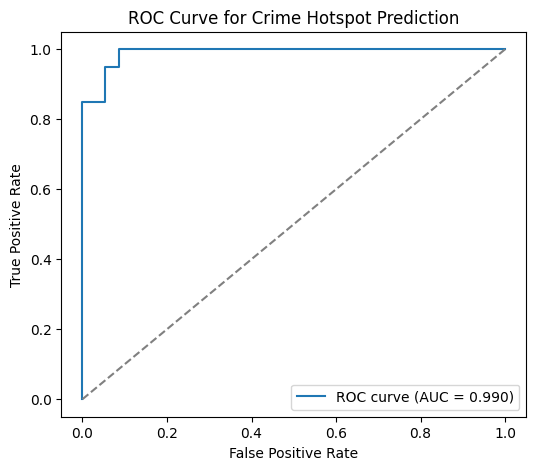

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Crime Hotspot Prediction")

plt.legend()

plt.show()

## ConfusionMatrix

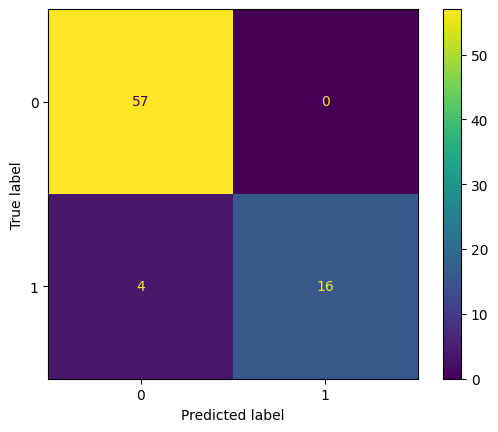

In [8]:
#ConfusionMatrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## Feature Importance Analysis

In [9]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 features")
print(importance.head(15))

Top 15 features
theft_ratio                 0.118504
battery_ratio               0.109440
lat_mean                    0.096679
commercial_ratio            0.090633
deceptive_practice_ratio    0.079394
other_ratio                 0.078380
criminal_damage_ratio       0.061704
other_crime_ratio           0.059933
residential_ratio           0.058303
public_ratio                0.051808
lon_mean                    0.050823
assault_ratio               0.029130
district_2                  0.018768
district_6                  0.017230
district_9                  0.012581
dtype: float64


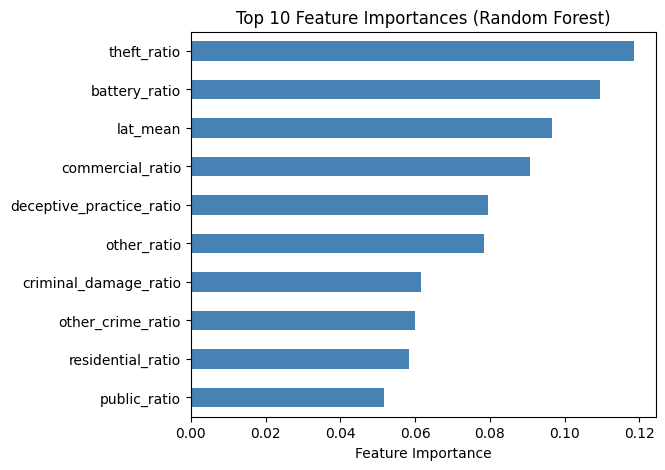

In [10]:
top_features = importance.head(10)

plt.figure(figsize=(6,5))

top_features.sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Random Forest)")

plt.show()

## Spatial Accuracy Evaluation

In [11]:
#Spatial accuracy evaluation
spatial_eval = pd.DataFrame({
    "community_area": range(1, 78),
    "y_true": y_test,
    "y_pred": y_pred,
    "y_prob": y_prob
})

spatial_eval["correct"] = (spatial_eval["y_true"] == spatial_eval["y_pred"]).astype(int)

print(spatial_eval)

    community_area  y_true  y_pred    y_prob  correct
0                1       0       0  0.033493        1
1                2       0       0  0.079694        1
2                3       1       0  0.368043        0
3                4       0       0  0.065223        1
4                5       0       0  0.237111        1
..             ...     ...     ...       ...      ...
72              73       0       0  0.171016        1
73              74       0       0  0.004450        1
74              75       0       0  0.009977        1
75              76       0       0  0.011991        1
76              77       0       0  0.049574        1

[77 rows x 5 columns]


In [12]:
wrong_areas = spatial_eval[spatial_eval["correct"] == 0]
print(wrong_areas)

    community_area  y_true  y_pred    y_prob  correct
2                3       1       0  0.368043        0
6                7       1       0  0.296253        0
18              19       1       0  0.376516        0
43              44       1       0  0.492741        0


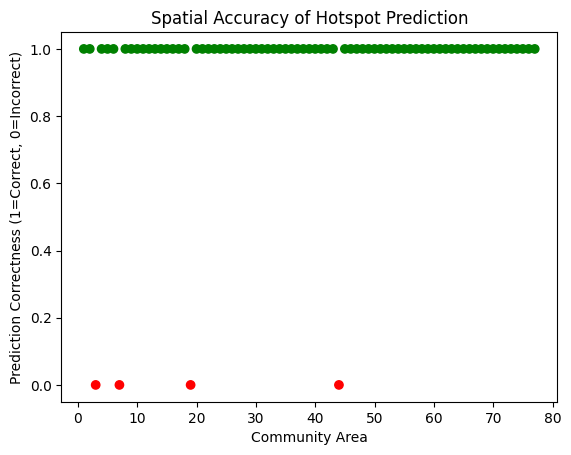

In [13]:
import matplotlib.pyplot as plt

colors = spatial_eval["correct"].map({1: "green", 0: "red"})

plt.scatter(
    spatial_eval["community_area"],
    spatial_eval["correct"],
    c=colors
)

plt.xlabel("Community Area")
plt.ylabel("Prediction Correctness (1=Correct, 0=Incorrect)")
plt.title("Spatial Accuracy of Hotspot Prediction")

plt.show()

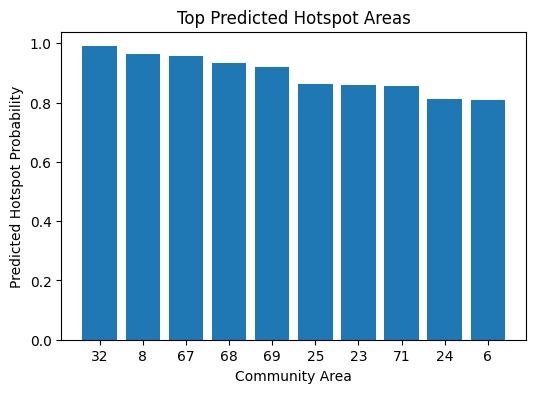

In [14]:
top_areas = spatial_eval.sort_values("y_prob", ascending=False).head(10)

plt.figure(figsize=(6,4))

plt.bar(
    top_areas["community_area"].astype(str),
    top_areas["y_prob"]
)

plt.xlabel("Community Area")
plt.ylabel("Predicted Hotspot Probability")
plt.title("Top Predicted Hotspot Areas")

plt.show()

In [15]:
# Build a working copy of test set with predictions
spatial_df = X_test.copy()
spatial_df['y_true'] = y_test
spatial_df['y_pred'] = y_pred
spatial_df['y_prob'] = y_prob

# Assign quadrant labels based on median lat/lon
lat_mid = spatial_df['lat_mean'].median()
lon_mid = spatial_df['lon_mean'].median()

def assign_quadrant(row):
    ns = 'North' if row['lat_mean'] >= lat_mid else 'South'
    ew = 'East'  if row['lon_mean'] >= lon_mid else 'West'
    return f'{ns}-{ew}'

spatial_df['quadrant'] = spatial_df.apply(assign_quadrant, axis=1)
print('Samples per quadrant:\n', spatial_df['quadrant'].value_counts())

# Evaluate per quadrant
spatial_results = []
for quad, grp in spatial_df.groupby('quadrant'):
    if grp['y_true'].nunique() < 2: 
        continue
    spatial_results.append({
        'Quadrant':  quad,
        'N':         len(grp),
        'Hotspot%':  f"{grp['y_true'].mean()*100:.1f}%",
        'Precision': precision_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'Recall':    recall_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'F1':        f1_score(grp['y_true'], grp['y_pred'], zero_division=0),
        'AUC-ROC':   roc_auc_score(grp['y_true'], grp['y_prob']),
    })

spatial_results_df = pd.DataFrame(spatial_results).set_index('Quadrant').round(4)
print('\n=== Spatial Accuracy by Quadrant ===')
print(spatial_results_df.to_string())

Samples per quadrant:
 quadrant
North-West    27
South-East    27
North-East    12
South-West    11
Name: count, dtype: int64

=== Spatial Accuracy by Quadrant ===
             N Hotspot%  Precision  Recall      F1  AUC-ROC
Quadrant                                                   
North-East  12    50.0%        1.0  0.6667  0.8000   1.0000
North-West  27    22.2%        1.0  0.8333  0.9091   0.9762
South-East  27    25.9%        1.0  0.8571  0.9231   1.0000
South-West  11     9.1%        1.0  1.0000  1.0000   1.0000


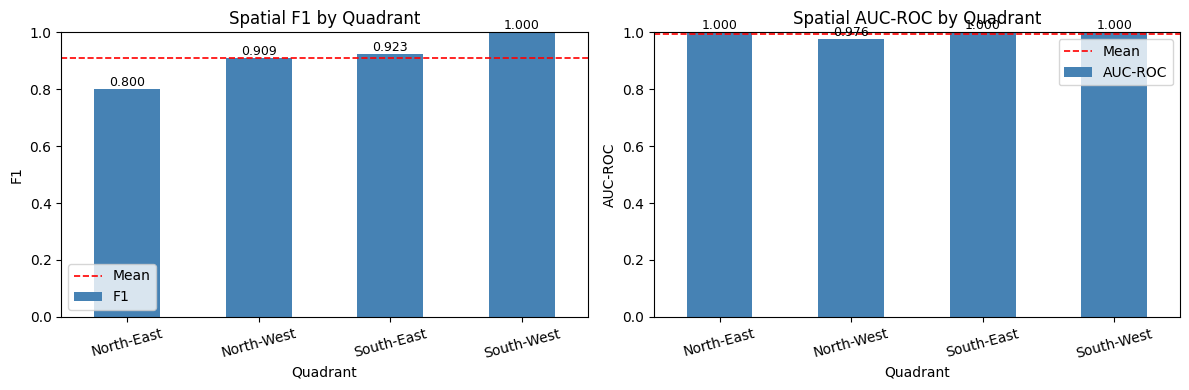

In [16]:
# Visualize spatial performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ['F1', 'AUC-ROC']):
    spatial_results_df[metric].plot(kind='bar', ax=ax, color='steelblue', rot=15)
    ax.set_title(f'Spatial {metric} by Quadrant')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.axhline(spatial_results_df[metric].mean(), color='red',
               linestyle='--', linewidth=1.2, label='Mean')
    ax.legend()
    for i, v in enumerate(spatial_results_df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../src/figures/random_forest_spatial.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
import joblib

# save model
joblib.dump(best_rf, "best_rf_model.pkl")

['best_rf_model.pkl']